#Импорты

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from ipywidgets import interact, FloatSlider

In [2]:
# =========================
# CONFIG
# =========================
SEED = 42

DATA_DIR = "./data"
OUT_DIR = "./out_ae"
os.makedirs(OUT_DIR, exist_ok=True)

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 20

LATENT_DIM = 4
NOISE_STD = 0.0

TRAIN_FC = True
TRAIN_CONV = True


FORCE_RETRAIN = True

# =========================
# DEVICE
# =========================
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

PIN_MEMORY = (DEVICE == "cuda")
NUM_WORKERS = 0

labeldict = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

print("DEVICE:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())
print("OUT_DIR:", OUT_DIR)

DEVICE: mps
CUDA available: False
MPS available: True
OUT_DIR: ./out_ae


In [3]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(SEED)

#загрузка датасета

In [4]:
transform = transforms.ToTensor()

trainset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

testset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train size:", len(trainset))
print("Test size:", len(testset))

img, label = trainset[0]
print("Sample image shape:", img.shape)
print("Sample label:", label, "-", labeldict[label])

Train size: 60000
Test size: 10000
Sample image shape: torch.Size([1, 28, 28])
Sample label: 9 - Ankle boot


#примеры картинок

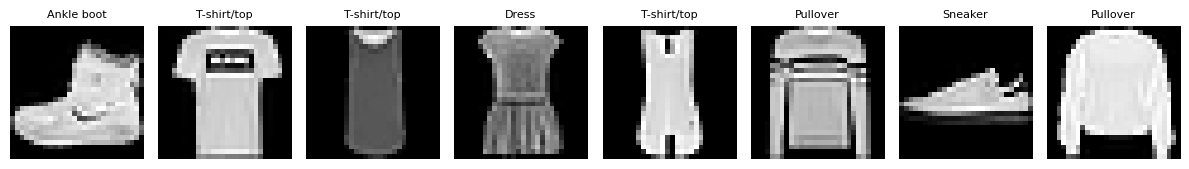

In [5]:
def show_samples(dataset, n=8):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i + 1)
        plt.imshow(img.squeeze(0), cmap="gray")
        plt.title(labeldict[label], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(trainset, n=8)

#модели

In [6]:
class FCAE(nn.Module):
    def __init__(self, latent_dim=4):
        super().__init__()
        self.latent_dim = latent_dim

        self.enc = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        b = x.size(0)
        x = x.view(b, -1)
        z = self.enc(x)
        return z

    def decode(self, z):
        x = self.dec(z)
        x = x.view(z.size(0), 1, 28, 28)
        return x

    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out


class ConvAE(nn.Module):
    def __init__(self, latent_dim=4):
        super().__init__()
        self.latent_dim = latent_dim

        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.ReLU()
        )

        self.enc_fc = nn.Linear(64 * 7 * 7, latent_dim)

        self.dec_fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(x.size(0), -1)
        z = self.enc_fc(h)
        return z

    def decode(self, z):
        h = self.dec_fc(z)
        h = h.view(z.size(0), 64, 7, 7)
        out = self.dec(h)
        return out

    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out

In [7]:
def get_model_path(model_name, latent_dim):
    return os.path.join(OUT_DIR, f"{model_name}_lat{latent_dim}.pth")


def save_checkpoint(model, model_name, latent_dim):
    path = get_model_path(model_name, latent_dim)
    torch.save({
        "model_name": model_name,
        "latent_dim": latent_dim,
        "state_dict": model.state_dict()
    }, path)
    print("Saved weights ->", path)


def load_checkpoint(model, model_name, latent_dim):
    path = get_model_path(model_name, latent_dim)
    ckpt = torch.load(path, map_location=torch.device(DEVICE))
    model.load_state_dict(ckpt["state_dict"])
    print("Loaded weights ->", path)
    return model

#функции для оценки, графиков и реконструкций

In [8]:
@torch.no_grad()
def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total = 0.0
    total_n = 0

    for x, _ in loader:
        x = x.to(DEVICE)
        r = model(x)
        loss = loss_fn(r, x)

        total += loss.item() * x.size(0)
        total_n += x.size(0)

    return total / total_n


def plot_losses(train_losses, test_losses=None, title="Loss"):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="train")
    if test_losses is not None:
        plt.plot(test_losses, label="test")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def save_loss_plot(train_losses, test_losses, filename, title):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="train")
    plt.plot(test_losses, label="test")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=160)
    plt.close()


@torch.no_grad()
def show_reconstructions(model, loader, n=8, title="Reconstructions"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    r = model(x)

    plt.figure(figsize=(2 * n, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].detach().cpu().squeeze(0), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Input", fontsize=12)

        plt.subplot(2, n, n + i + 1)
        plt.imshow(r[i].detach().cpu().squeeze(0), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Recon", fontsize=12)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def save_reconstructions(model, loader, filename, n=8, title="Reconstructions"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    r = model(x)

    plt.figure(figsize=(2 * n, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].detach().cpu().squeeze(0), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Input", fontsize=12)

        plt.subplot(2, n, n + i + 1)
        plt.imshow(r[i].detach().cpu().squeeze(0), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Recon", fontsize=12)

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=160)
    plt.close()

#обучение или загрузка модели

In [9]:
def train_or_load_model(model, model_name, train_loader, test_loader,
                        epochs=20, lr=1e-3, noise_std=0.0, force_retrain=False):
    model = model.to(DEVICE)
    path = get_model_path(model_name, model.latent_dim)
    loss_fn = nn.MSELoss()

    if os.path.exists(path) and not force_retrain:
        model = load_checkpoint(model, model_name, model.latent_dim)
        model.eval()
        print(f"{model_name}: использованы сохраненные веса")
        return model, None, None

    print(f"{model_name}: старт обучения")
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_sum = 0.0
        total_n = 0

        for x, _ in train_loader:
            x = x.to(DEVICE)

            x_in = x
            if noise_std > 0:
                x_in = (x + noise_std * torch.randn_like(x)).clamp(0, 1)

            optimizer.zero_grad(set_to_none=True)
            r = model(x_in)
            loss = loss_fn(r, x)
            loss.backward()
            optimizer.step()

            train_sum += loss.item() * x.size(0)
            total_n += x.size(0)

        train_loss = train_sum / total_n
        test_loss = evaluate_loss(model, test_loader, loss_fn)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        print(f"[{model_name}] epoch {epoch:03d}/{epochs} | train={train_loss:.6f} | test={test_loss:.6f}")

    save_checkpoint(model, model_name, model.latent_dim)

    save_loss_plot(
        train_losses,
        test_losses,
        filename=f"{model_name}_lat{model.latent_dim}_loss.png",
        title=f"{model_name} loss"
    )

    save_reconstructions(
        model,
        test_loader,
        filename=f"{model_name}_lat{model.latent_dim}_recon.png",
        n=8,
        title=f"{model_name} reconstructions"
    )

    return model, train_losses, test_losses

запуск FC AutoEncoder

In [10]:
fc_model = None
fc_train_losses = None
fc_test_losses = None

if TRAIN_FC:
    fc_model = FCAE(latent_dim=LATENT_DIM)
    fc_model, fc_train_losses, fc_test_losses = train_or_load_model(
        model=fc_model,
        model_name="fc_ae",
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        noise_std=NOISE_STD,
        force_retrain=FORCE_RETRAIN
    )

fc_ae: старт обучения
[fc_ae] epoch 001/20 | train=0.037254 | test=0.023293
[fc_ae] epoch 002/20 | train=0.022207 | test=0.021483
[fc_ae] epoch 003/20 | train=0.020929 | test=0.020561
[fc_ae] epoch 004/20 | train=0.020269 | test=0.020079
[fc_ae] epoch 005/20 | train=0.019848 | test=0.019778
[fc_ae] epoch 006/20 | train=0.019546 | test=0.019586
[fc_ae] epoch 007/20 | train=0.019303 | test=0.019331
[fc_ae] epoch 008/20 | train=0.019081 | test=0.019215
[fc_ae] epoch 009/20 | train=0.018923 | test=0.019058
[fc_ae] epoch 010/20 | train=0.018788 | test=0.019100
[fc_ae] epoch 011/20 | train=0.018635 | test=0.018799
[fc_ae] epoch 012/20 | train=0.018500 | test=0.018762
[fc_ae] epoch 013/20 | train=0.018399 | test=0.018592
[fc_ae] epoch 014/20 | train=0.018286 | test=0.018557
[fc_ae] epoch 015/20 | train=0.018170 | test=0.018382
[fc_ae] epoch 016/20 | train=0.018076 | test=0.018371
[fc_ae] epoch 017/20 | train=0.017998 | test=0.018391
[fc_ae] epoch 018/20 | train=0.017920 | test=0.018272
[fc_ae

график ошибки FC

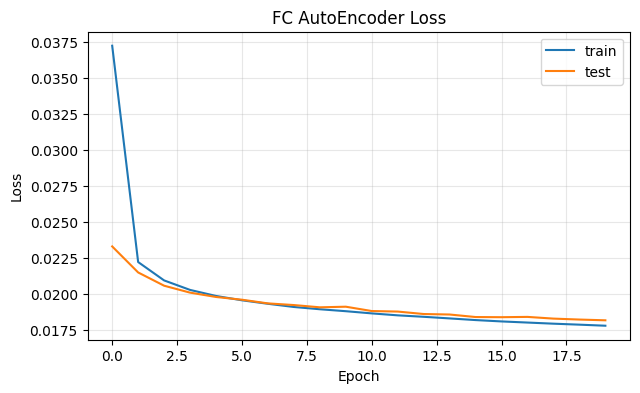

In [11]:
if fc_train_losses is not None:
    plot_losses(fc_train_losses, fc_test_losses, title="FC AutoEncoder Loss")


реконструкции FC

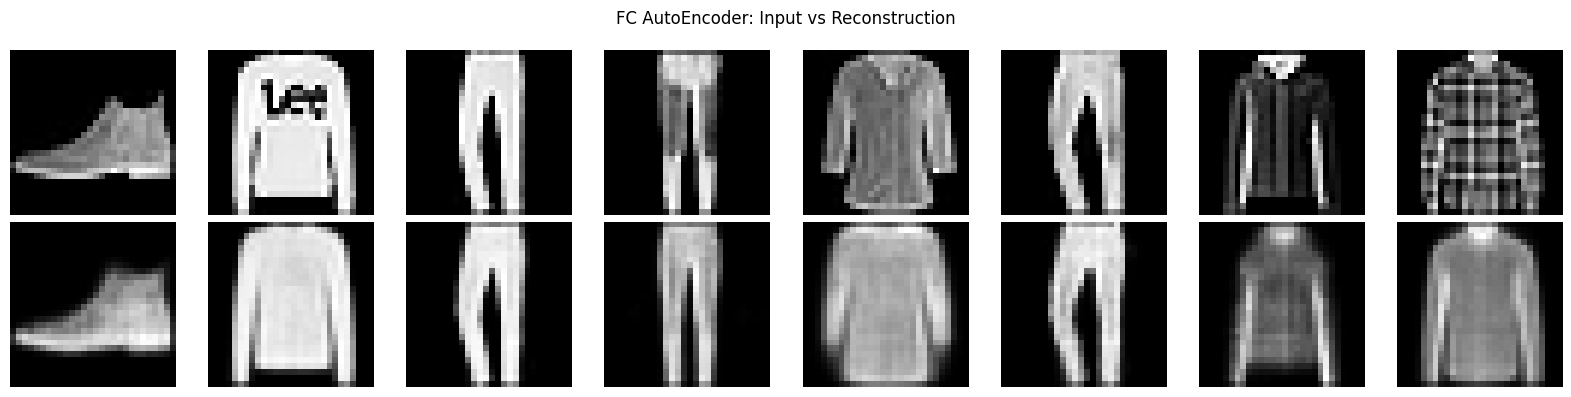

In [12]:
if fc_model is not None:
    show_reconstructions(fc_model, test_loader, n=8, title="FC AutoEncoder: Input vs Reconstruction")

запуск Conv AutoEncoder

In [13]:
conv_model = None
conv_train_losses = None
conv_test_losses = None

if TRAIN_CONV:
    conv_model = ConvAE(latent_dim=LATENT_DIM)
    conv_model, conv_train_losses, conv_test_losses = train_or_load_model(
        model=conv_model,
        model_name="conv_ae",
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        noise_std=NOISE_STD,
        force_retrain=FORCE_RETRAIN
    )

conv_ae: старт обучения
[conv_ae] epoch 001/20 | train=0.038208 | test=0.026936
[conv_ae] epoch 002/20 | train=0.025338 | test=0.024426
[conv_ae] epoch 003/20 | train=0.023711 | test=0.023411
[conv_ae] epoch 004/20 | train=0.022764 | test=0.022604
[conv_ae] epoch 005/20 | train=0.022159 | test=0.022186
[conv_ae] epoch 006/20 | train=0.021725 | test=0.021768
[conv_ae] epoch 007/20 | train=0.021431 | test=0.021399
[conv_ae] epoch 008/20 | train=0.021176 | test=0.021290
[conv_ae] epoch 009/20 | train=0.020991 | test=0.021092
[conv_ae] epoch 010/20 | train=0.020828 | test=0.020953
[conv_ae] epoch 011/20 | train=0.020706 | test=0.020921
[conv_ae] epoch 012/20 | train=0.020602 | test=0.020727
[conv_ae] epoch 013/20 | train=0.020497 | test=0.020672
[conv_ae] epoch 014/20 | train=0.020397 | test=0.020532
[conv_ae] epoch 015/20 | train=0.020310 | test=0.020615
[conv_ae] epoch 016/20 | train=0.020260 | test=0.020502
[conv_ae] epoch 017/20 | train=0.020178 | test=0.020384
[conv_ae] epoch 018/20 |

график ошибки Conv

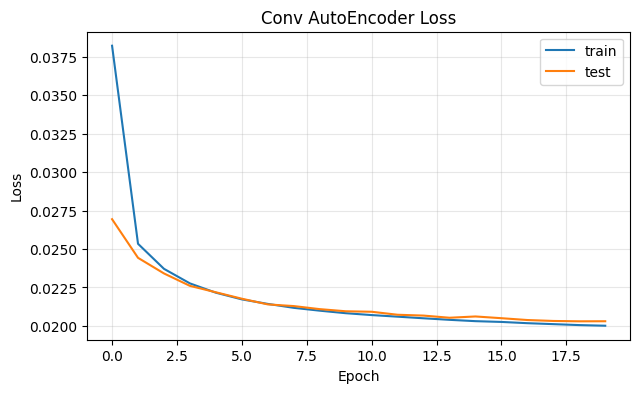

In [14]:
if conv_train_losses is not None:
    plot_losses(conv_train_losses, conv_test_losses, title="Conv AutoEncoder Loss")
else:
    print("Conv модель загружена из файла. График уже сохранен в папке out_ae.")

реконструкции Conv

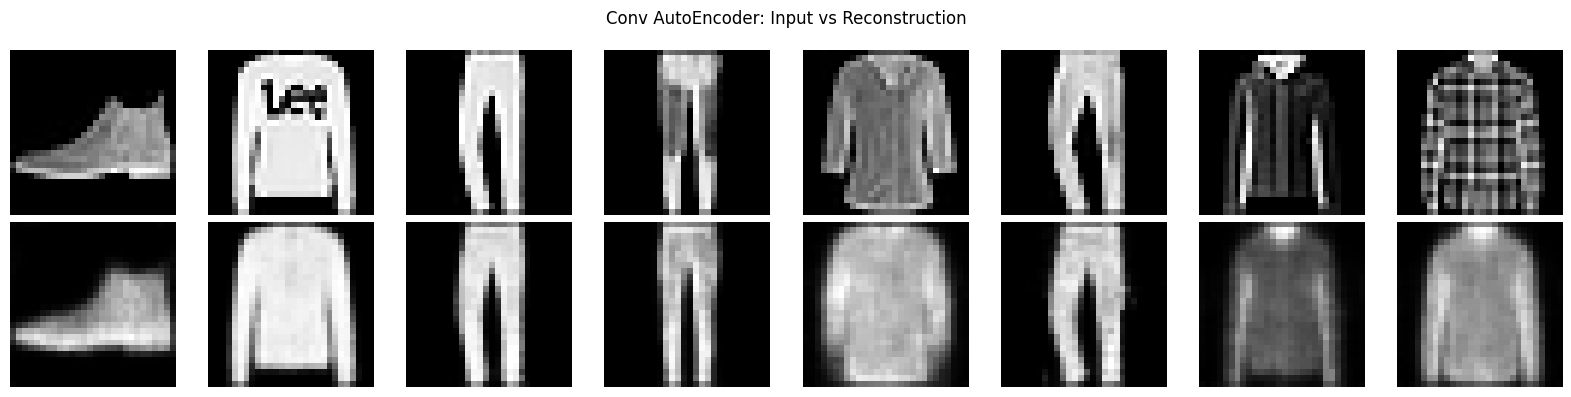

In [15]:
if conv_model is not None:
    show_reconstructions(conv_model, test_loader, n=8, title="Conv AutoEncoder: Input vs Reconstruction")

PCA визуализация латентного пространства

In [16]:
@torch.no_grad()
def plot_latent_pca(model, loader, max_points=3000, title="Latent PCA"):
    model.eval()

    Z = []
    Y = []
    total = 0

    for x, y in loader:
        x = x.to(DEVICE)
        z = model.encode(x).detach().cpu().numpy()

        Z.append(z)
        Y.append(y.numpy())

        total += x.size(0)
        if total >= max_points:
            break

    Z = np.concatenate(Z, axis=0)[:max_points]
    Y = np.concatenate(Y, axis=0)[:max_points]

    pca = PCA(n_components=2)
    Z2 = pca.fit_transform(Z)

    plt.figure(figsize=(10, 7))
    sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=Y, s=8)
    plt.colorbar(sc)
    plt.title(title)

    for i in range(10):
        pts = Z2[Y == i]
        if len(pts) > 0:
            center = pts.mean(axis=0)
            plt.text(center[0], center[1], f"{labeldict[i]} ({i})", fontsize=9, ha="center")

    plt.tight_layout()
    plt.show()

PCA для FC

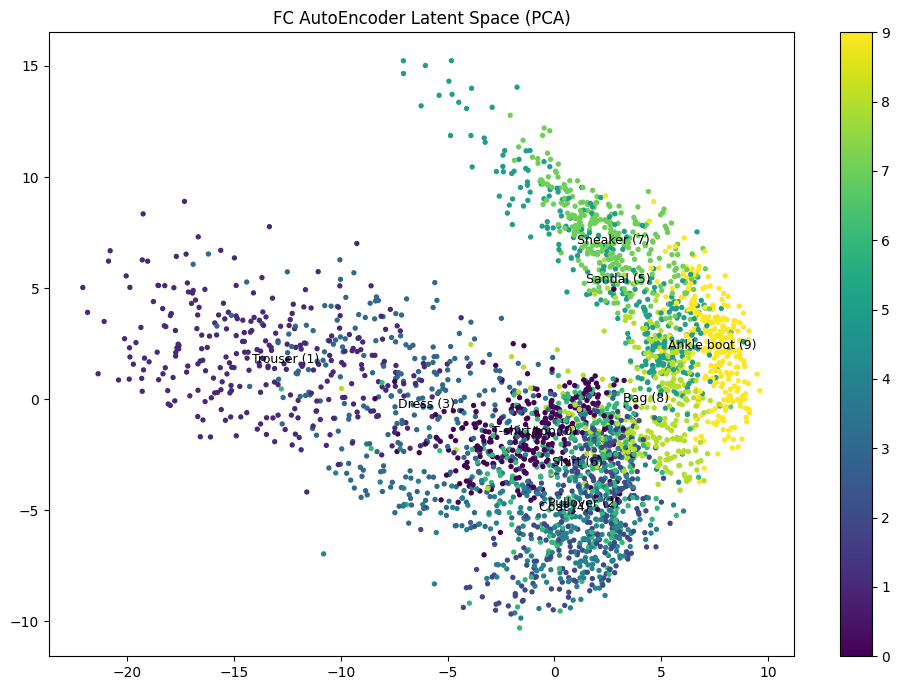

In [17]:
if fc_model is not None:
    plot_latent_pca(fc_model, test_loader, title="FC AutoEncoder Latent Space (PCA)")

PCA для Conv

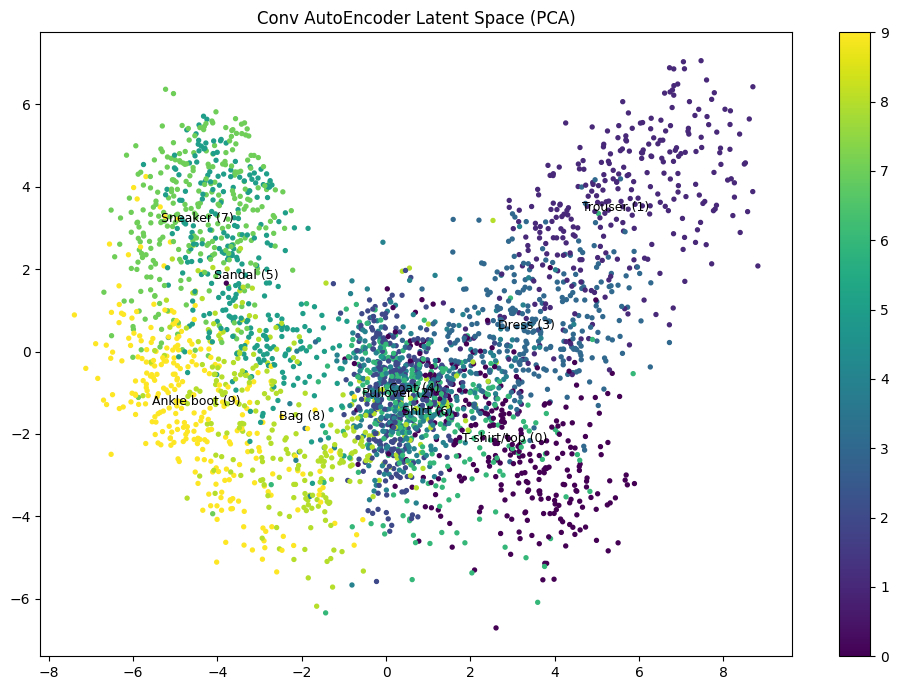

In [18]:
if conv_model is not None:
    plot_latent_pca(conv_model, test_loader, title="Conv AutoEncoder Latent Space (PCA)")

интерактивный декодер

In [19]:
def interactive_decoder(model, z_range=3.0):
    assert model.latent_dim == 4

    @torch.no_grad()
    def decode_and_show(z1=0.0, z2=0.0, z3=0.0, z4=0.0):
        model.eval()

        z = torch.tensor([[z1, z2, z3, z4]], dtype=torch.float32, device=DEVICE)
        img = model.decode(z)[0, 0].detach().cpu().numpy()

        plt.figure(figsize=(3, 3))
        plt.imshow(img, cmap="gray")
        plt.title("Decoded from latent vector")
        plt.axis("off")
        plt.show()

    interact(
        decode_and_show,
        z1=FloatSlider(min=-z_range, max=z_range, step=0.1, value=0.0),
        z2=FloatSlider(min=-z_range, max=z_range, step=0.1, value=0.0),
        z3=FloatSlider(min=-z_range, max=z_range, step=0.1, value=0.0),
        z4=FloatSlider(min=-z_range, max=z_range, step=0.1, value=0.0),
    )

интерактивный декодер для FC

In [20]:
if fc_model is not None:
    interactive_decoder(fc_model, z_range=3.0)

interactive(children=(FloatSlider(value=0.0, description='z1', max=3.0, min=-3.0), FloatSlider(value=0.0, desc…

интерактивный декодер для Conv

In [21]:
if conv_model is not None:
    interactive_decoder(conv_model, z_range=3.0)

interactive(children=(FloatSlider(value=0.0, description='z1', max=3.0, min=-3.0), FloatSlider(value=0.0, desc…

отдельно загрузить только готовые веса без обучения

In [22]:
fc_model = FCAE(latent_dim=LATENT_DIM).to(DEVICE)
fc_model = load_checkpoint(fc_model, "fc_ae", LATENT_DIM)
fc_model.eval()

conv_model = ConvAE(latent_dim=LATENT_DIM).to(DEVICE)
conv_model = load_checkpoint(conv_model, "conv_ae", LATENT_DIM)
conv_model.eval()

Loaded weights -> ./out_ae/fc_ae_lat4.pth
Loaded weights -> ./out_ae/conv_ae_lat4.pth


ConvAE(
  (enc): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (enc_fc): Linear(in_features=3136, out_features=4, bias=True)
  (dec_fc): Linear(in_features=4, out_features=3136, bias=True)
  (dec): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)